Financial institutions process millions of transactions daily. Detecting fraudulent transactions is essential to prevent financial losses and maintain customer trust.

This project analyzes financial transaction data to identify patterns associated with fraudulent behavior. Using statistical analysis and visualization, the project explores how factors such as transaction amount, customer behavior, and transaction frequency relate to fraud risk.

Tools Used:

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'Transaction_ID': np.arange(1,n+1),
    'Customer_ID': np.random.randint(1000,1100,n),
    'Transaction_Amount': np.random.exponential(scale=200, size=n),
    'Transaction_Time': np.random.randint(0,24,n),
    'Location_Risk': np.random.choice([0,1],n,p=[0.8,0.2]),
    'Previous_Fraud': np.random.choice([0,1],n,p=[0.9,0.1]),
})

df['Fraud'] = (
    (df['Transaction_Amount'] > 600) |
    (df['Location_Risk']==1) & (df['Previous_Fraud']==1)
).astype(int)

df.head()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Time,Location_Risk,Previous_Fraud,Fraud
0,1,1051,176.784612,17,0,0,0
1,2,1092,273.643330,12,1,0,0
2,3,1014,113.006930,1,0,0,0
3,4,1071,27.296933,8,0,0,0
4,5,1060,66.752436,20,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      1000 non-null   int64  
 1   Customer_ID         1000 non-null   int64  
 2   Transaction_Amount  1000 non-null   float64
 3   Transaction_Time    1000 non-null   int64  
 4   Location_Risk       1000 non-null   int64  
 5   Previous_Fraud      1000 non-null   int64  
 6   Fraud               1000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


In [5]:
df.describe()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Time,Location_Risk,Previous_Fraud,Fraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1049.128000,201.117323,11.784000,0.191000,0.090000,0.071000
std,288.819436,29.573505,201.684920,7.022582,0.393286,0.286325,0.256953
min,1.000000,1000.000000,0.928557,0.000000,0.000000,0.000000,0.000000
25%,250.750000,1023.000000,54.135560,6.000000,0.000000,0.000000,0.000000
50%,500.500000,1050.000000,142.733672,12.000000,0.000000,0.000000,0.000000
75%,750.250000,1074.000000,272.217224,18.000000,0.000000,0.000000,0.000000
max,1000.000000,1099.000000,1488.344582,23.000000,1.000000,1.000000,1.000000


The dataset contains 1000 simulated financial transactions with attributes such as transaction amount, transaction time, and fraud indicators. The target variable indicates whether a transaction is fraudulent.


In [6]:
df['Fraud'].value_counts()

,count
Fraud,
0,929
1,71


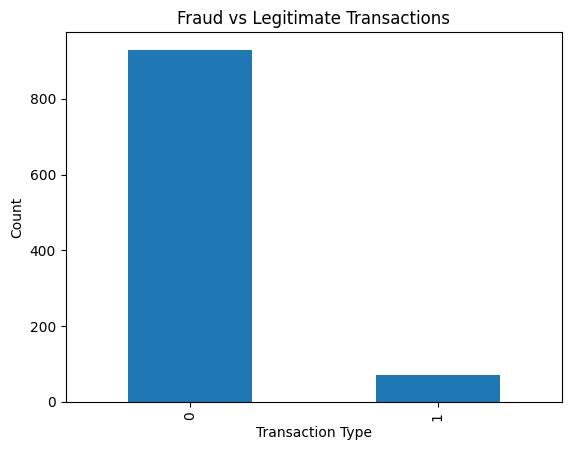

In [7]:
df['Fraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

Fraudulent transactions represent a smaller portion of the dataset, reflecting real-world banking environments where fraud cases are relatively rare but high-impact.


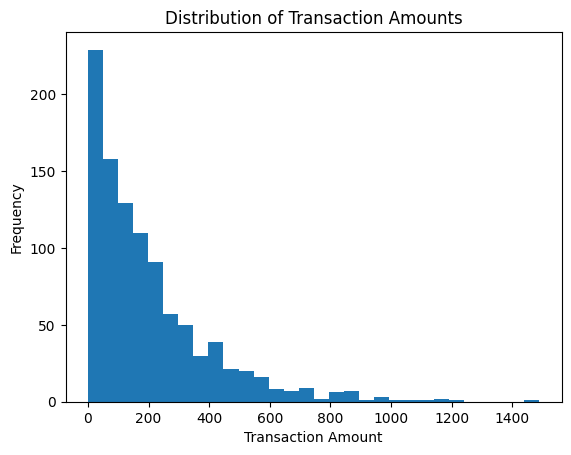

In [8]:
plt.hist(df['Transaction_Amount'], bins=30)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

Most transactions are small to medium in value, while a few high-value transactions appear as outliers. Such transactions often require additional fraud monitoring.


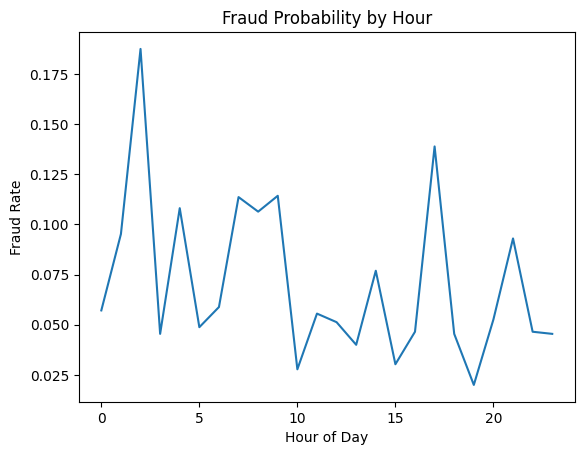

In [9]:
df.groupby('Transaction_Time')['Fraud'].mean().plot()

plt.title("Fraud Probability by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")

plt.show()

Fraud probability varies throughout the day. Late-night or unusual transaction times may indicate suspicious activity patterns.


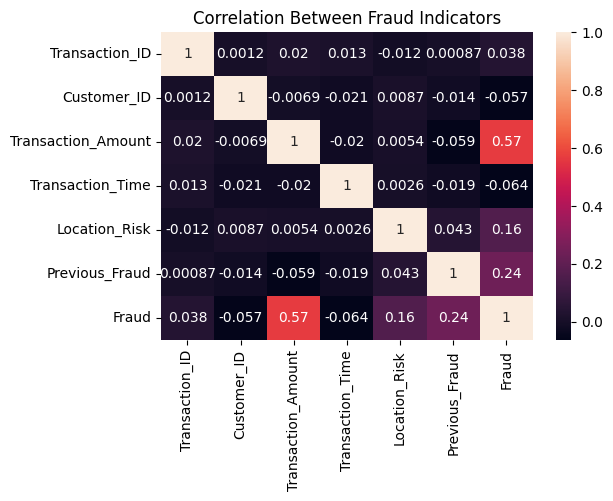

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Between Fraud Indicators")

plt.show()

The heatmap reveals relationships between transaction attributes and fraud occurrence. Transaction amount and prior fraud history show stronger correlations with fraudulent activity.


In [11]:
df['Risk_Level'] = pd.cut(
    df['Transaction_Amount'],
    bins=[0,100,500,1000],
    labels=['Low','Medium','High']
)

df.groupby('Risk_Level')['Fraud'].mean()

/tmp/ipykernel_198/1742692274.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Risk_Level')['Fraud'].mean()


,Fraud
Risk_Level,
Low,0.025840
Medium,0.020833
High,0.551282


High-value transactions exhibit a significantly higher fraud rate. Risk segmentation can help financial institutions prioritize monitoring resources.


Conclusion

This analysis demonstrates how transaction data can be used to identify patterns associated with financial fraud. Key insights include:

• High-value transactions are more likely to be fraudulent.

• Customers with prior fraud history present higher risk.

• Transaction timing can influence fraud probability.

These findings highlight the importance of transaction monitoring systems in modern banking. Data-driven approaches enable financial institutions to detect fraud efficiently and reduce financial losses.
